<a href="https://colab.research.google.com/github/subani1323/Database_Assignment/blob/main/Database_Assignment_Section_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Install packages (run once only)
install.packages("dplyr")
install.packages("ggplot2")
install.packages("sqldf")

# Load libraries
library(dplyr)
library(ggplot2)
library(sqldf)

# Base GitHub URL
base_url <- "https://raw.githubusercontent.com/subani1323/Database_Assignment/main/"


deliveries <- read.csv(paste0(base_url, "deliveries.csv"))

head(deliveries)
str(deliveries)



Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

also installing the dependencies ‘gsubfn’, ‘proto’, ‘RSQLite’, ‘chron’



Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union


Loading required package: gsubfn

Loading required package: proto

Warning message:
“no DISPLAY variable so Tk is not available”
Loading required package: RSQLite



,delivery_id,order_id,driver_id,vehicle_id,hub_id,dispatch_time,delivery_completed_at,delivery_status,route_distance_km,manual_route_override_count,proof_of_completion_missing,customer_rating_post_delivery,fuel_or_charge_cost
,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<dbl>,<int>,<int>,<dbl>,<dbl>
1,DL00001,O00938,D004,V056,H05,2024-06-18 10:57:00,2024-06-19 09:05:59.904311,Failed,17.26,1,0,3.07,12.05
2,DL00002,O00004,D138,V007,H02,2025-01-11 18:45:00,2025-01-11 17:39:00.000000,OnTime,10.34,1,0,5.00,13.41
3,DL00003,O00639,D006,V049,H02,2025-06-02 20:39:00,2025-06-02 21:45:32.366770,OnTime,7.92,0,0,4.98,8.51
4,DL00004,O00313,D116,V055,H02,2024-03-08 23:31:00,2024-03-09 23:30:08.103702,Delayed,16.42,0,0,4.18,13.62
5,DL00005,O00844,D108,V034,H01,2025-09-21 11:43:00,2025-09-21 15:45:34.131056,OnTime,14.52,1,0,4.18,9.22
6,DL00006,O00029,D037,V098,H03,2024-09-11 12:40:00,2024-09-12 17:11:52.384869,Delayed,13.84,0,0,1.57,9.58


'data.frame':	950 obs. of  13 variables:
 $ delivery_id                  : chr  "DL00001" "DL00002" "DL00003" "DL00004" ...
 $ order_id                     : chr  "O00938" "O00004" "O00639" "O00313" ...
 $ driver_id                    : chr  "D004" "D138" "D006" "D116" ...
 $ vehicle_id                   : chr  "V056" "V007" "V049" "V055" ...
 $ hub_id                       : chr  "H05" "H02" "H02" "H02" ...
 $ dispatch_time                : chr  "2024-06-18 10:57:00" "2025-01-11 18:45:00" "2025-06-02 20:39:00" "2024-03-08 23:31:00" ...
 $ delivery_completed_at        : chr  "2024-06-19 09:05:59.904311" "2025-01-11 17:39:00.000000" "2025-06-02 21:45:32.366770" "2024-03-09 23:30:08.103702" ...
 $ delivery_status              : chr  "Failed" "OnTime" "OnTime" "Delayed" ...
 $ route_distance_km            : num  17.26 10.34 7.92 16.42 14.52 ...
 $ manual_route_override_count  : int  1 1 0 0 1 0 0 1 1 1 ...
 $ proof_of_completion_missing  : int  0 0 0 0 0 0 0 0 0 0 ...
 $ customer_rating_p

In [ ]:
sqldf("
SELECT delivery_id, order_id, driver_id, hub_id, delivery_status,
       dispatch_time, delivery_completed_at,
       ROUND((julianday(delivery_completed_at) - julianday(dispatch_time)) * 1440, 2) AS delivery_minutes
FROM deliveries
WHERE dispatch_time IS NOT NULL
  AND delivery_completed_at IS NOT NULL
  AND (julianday(delivery_completed_at) - julianday(dispatch_time)) * 1440 > 60
ORDER BY delivery_minutes DESC
")

delivery_id,order_id,driver_id,hub_id,delivery_status,dispatch_time,delivery_completed_at,delivery_minutes
<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<dbl>
DL00386,O00135,D144,H05,Failed,2025-04-25 03:12:00,2025-04-26 22:39:24.905513,2607.42
DL00387,O00274,D016,H01,Failed,2025-10-03 21:33:00,2025-10-05 15:40:35.899437,2527.60
DL00033,O00885,D041,H06,Failed,2024-11-17 14:01:00,2024-11-19 06:51:25.201294,2450.42
DL00530,O00756,D095,H01,Failed,2025-02-03 18:06:00,2025-02-05 09:39:56.840261,2373.95
DL00026,O00906,D092,H04,Failed,2025-02-04 11:16:00,2025-02-06 01:48:45.831712,2312.76
DL00806,O00128,D117,H07,Delayed,2025-12-28 14:40:00,2025-12-30 04:18:53.684717,2258.89
DL00497,O00192,D083,H08,Failed,2025-08-18 14:17:00,2025-08-20 03:34:36.170242,2237.60
DL00472,O00042,D113,H01,Delayed,2025-12-01 19:10:00,2025-12-03 08:16:03.110618,2226.05
DL00775,O00153,D109,H05,Delayed,2025-02-09 09:08:00,2025-02-10 21:51:56.051970,2203.93


In [ ]:
sqldf("
SELECT delivery_id, order_id, driver_id, hub_id, delivery_status
FROM deliveries
WHERE delivery_status = 'Failed'
")

delivery_id,order_id,driver_id,hub_id,delivery_status
<chr>,<chr>,<chr>,<chr>,<chr>
DL00001,O00938,D004,H05,Failed
DL00010,O00836,D058,H08,Failed
DL00012,O01207,D051,H05,Failed
DL00022,O01027,D088,H07,Failed
DL00026,O00906,D092,H04,Failed
DL00033,O00885,D041,H06,Failed
DL00038,O00727,D096,H02,Failed
DL00039,O00542,D090,H08,Failed
DL00040,O00919,D027,H04,Failed


In [ ]:
sqldf("
SELECT *
FROM (
  SELECT * FROM deliveries
  UNION ALL
  SELECT
    'DL9999','O9999','D001','V001','H01',
    '2024-01-01 10:00:00','2024-01-01 11:30:00','Completed',
    12.5,1,0,4.5,20.00
)
WHERE delivery_id = 'DL9999'
")

delivery_id,order_id,driver_id,vehicle_id,hub_id,dispatch_time,delivery_completed_at,delivery_status,route_distance_km,manual_route_override_count,proof_of_completion_missing,customer_rating_post_delivery,fuel_or_charge_cost
<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<dbl>,<int>,<int>,<dbl>,<dbl>
DL9999,O9999,D001,V001,H01,2024-01-01 10:00:00,2024-01-01 11:30:00,Completed,12.5,1,0,4.5,20


In [ ]:
sqldf("
SELECT *
FROM (
  SELECT * FROM deliveries
  UNION ALL
  SELECT
    'DL2001','O2001','D020','V020','H03',
    '2024-03-10 08:15:00','2024-03-10 10:45:00','Completed',
    15.2,1,0,4.7,22.30
  UNION ALL
  SELECT
    'DL2002','O2002','D021','V021','H04',
    '2024-04-05 13:20:00','2024-04-05 17:10:00','Delayed',
    25.6,2,1,3.6,35.75
)
WHERE delivery_id IN ('DL2001','DL2002')
")

delivery_id,order_id,driver_id,vehicle_id,hub_id,dispatch_time,delivery_completed_at,delivery_status,route_distance_km,manual_route_override_count,proof_of_completion_missing,customer_rating_post_delivery,fuel_or_charge_cost
<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<dbl>,<int>,<int>,<dbl>,<dbl>
DL2001,O2001,D020,V020,H03,2024-03-10 08:15:00,2024-03-10 10:45:00,Completed,15.2,1,0,4.7,22.30
DL2002,O2002,D021,V021,H04,2024-04-05 13:20:00,2024-04-05 17:10:00,Delayed,25.6,2,1,3.6,35.75


In [ ]:
sqldf("
SELECT
  delivery_id, order_id, driver_id, vehicle_id, hub_id,
  dispatch_time, delivery_completed_at,
  CASE
    WHEN delivery_id = 'DL2001' THEN 'Completed'
    ELSE delivery_status
  END AS delivery_status,
  route_distance_km, manual_route_override_count,
  proof_of_completion_missing, customer_rating_post_delivery,
  fuel_or_charge_cost
FROM (
  SELECT * FROM deliveries
  UNION ALL
  SELECT
    'DL2001','O2001','D020','V020','H03',
    '2024-03-10 08:15:00','2024-03-10 10:45:00','Delayed',
    15.2,1,0,4.7,22.30
)
WHERE delivery_id = 'DL2001'
")

delivery_id,order_id,driver_id,vehicle_id,hub_id,dispatch_time,delivery_completed_at,delivery_status,route_distance_km,manual_route_override_count,proof_of_completion_missing,customer_rating_post_delivery,fuel_or_charge_cost
<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<dbl>,<int>,<int>,<dbl>,<dbl>
DL2001,O2001,D020,V020,H03,2024-03-10 08:15:00,2024-03-10 10:45:00,Completed,15.2,1,0,4.7,22.3


In [ ]:
sqldf("
SELECT
  delivery_id, order_id, driver_id, vehicle_id, hub_id,
  dispatch_time, delivery_completed_at, delivery_status,
  route_distance_km, manual_route_override_count,
  proof_of_completion_missing,
  CASE
    WHEN delivery_id = 'DL2002' THEN 4.9
    ELSE customer_rating_post_delivery
  END AS customer_rating_post_delivery,
  CASE
    WHEN delivery_id = 'DL2002' THEN 40.00
    ELSE fuel_or_charge_cost
  END AS fuel_or_charge_cost
FROM (
  SELECT * FROM deliveries
  UNION ALL
  SELECT
    'DL2002','O2002','D021','V021','H04',
    '2024-04-05 13:20:00','2024-04-05 17:10:00','Delayed',
    25.6,2,1,3.6,35.75
)
WHERE delivery_id = 'DL2002'
")

delivery_id,order_id,driver_id,vehicle_id,hub_id,dispatch_time,delivery_completed_at,delivery_status,route_distance_km,manual_route_override_count,proof_of_completion_missing,customer_rating_post_delivery,fuel_or_charge_cost
<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<dbl>,<int>,<int>,<dbl>,<dbl>
DL2002,O2002,D021,V021,H04,2024-04-05 13:20:00,2024-04-05 17:10:00,Delayed,25.6,2,1,4.9,40


In [ ]:
sqldf("
SELECT *
FROM (
  SELECT * FROM deliveries
  UNION ALL
  SELECT
    'DL2001','O2001','D020','V020','H03',
    '2024-03-10 08:15:00','2024-03-10 10:45:00','Delayed',
    15.2,1,0,4.7,22.30
)
WHERE delivery_id != 'DL2001'
")

delivery_id,order_id,driver_id,vehicle_id,hub_id,dispatch_time,delivery_completed_at,delivery_status,route_distance_km,manual_route_override_count,proof_of_completion_missing,customer_rating_post_delivery,fuel_or_charge_cost
<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<dbl>,<int>,<int>,<dbl>,<dbl>
DL00001,O00938,D004,V056,H05,2024-06-18 10:57:00,2024-06-19 09:05:59.904311,Failed,17.26,1,0,3.07,12.05
DL00002,O00004,D138,V007,H02,2025-01-11 18:45:00,2025-01-11 17:39:00.000000,OnTime,10.34,1,0,5.00,13.41
DL00003,O00639,D006,V049,H02,2025-06-02 20:39:00,2025-06-02 21:45:32.366770,OnTime,7.92,0,0,4.98,8.51
DL00004,O00313,D116,V055,H02,2024-03-08 23:31:00,2024-03-09 23:30:08.103702,Delayed,16.42,0,0,4.18,13.62
DL00005,O00844,D108,V034,H01,2025-09-21 11:43:00,2025-09-21 15:45:34.131056,OnTime,14.52,1,0,4.18,9.22
DL00006,O00029,D037,V098,H03,2024-09-11 12:40:00,2024-09-12 17:11:52.384869,Delayed,13.84,0,0,1.57,9.58
DL00007,O00097,D151,V037,H07,2024-01-09 13:41:00,2024-01-10 23:39:11.072850,Delayed,32.72,0,0,4.64,17.70
DL00008,O00207,D082,V066,H03,2024-08-22 21:34:00,2024-08-22 23:22:21.531162,OnTime,7.16,1,0,3.76,11.66
DL00009,O00297,D088,V029,H05,2024-04-12 21:33:00,2024-04-13 01:18:52.673288,OnTime,40.23,1,0,3.70,15.78


In [ ]:
sqldf("
SELECT *
FROM deliveries
WHERE delivery_status != 'Delayed'
")

delivery_id,order_id,driver_id,vehicle_id,hub_id,dispatch_time,delivery_completed_at,delivery_status,route_distance_km,manual_route_override_count,proof_of_completion_missing,customer_rating_post_delivery,fuel_or_charge_cost
<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<dbl>,<int>,<int>,<dbl>,<dbl>
DL00001,O00938,D004,V056,H05,2024-06-18 10:57:00,2024-06-19 09:05:59.904311,Failed,17.26,1,0,3.07,12.05
DL00002,O00004,D138,V007,H02,2025-01-11 18:45:00,2025-01-11 17:39:00.000000,OnTime,10.34,1,0,5.00,13.41
DL00003,O00639,D006,V049,H02,2025-06-02 20:39:00,2025-06-02 21:45:32.366770,OnTime,7.92,0,0,4.98,8.51
DL00005,O00844,D108,V034,H01,2025-09-21 11:43:00,2025-09-21 15:45:34.131056,OnTime,14.52,1,0,4.18,9.22
DL00008,O00207,D082,V066,H03,2024-08-22 21:34:00,2024-08-22 23:22:21.531162,OnTime,7.16,1,0,3.76,11.66
DL00009,O00297,D088,V029,H05,2024-04-12 21:33:00,2024-04-13 01:18:52.673288,OnTime,40.23,1,0,3.70,15.78
DL00010,O00836,D058,V057,H08,2025-09-22 19:09:00,2025-09-23 01:15:29.151459,Failed,9.85,1,0,3.20,9.31
DL00011,O00202,D074,V117,H04,2024-02-02 03:09:00,2024-02-02 02:29:05.367622,OnTime,13.85,0,0,4.36,15.17
DL00012,O01207,D051,V017,H05,2024-12-26 19:41:00,2024-12-27 09:26:05.387672,Failed,16.96,3,0,NA,16.98


In [ ]:
sqldf("
SELECT delivery_status,
       ROUND(AVG(fuel_or_charge_cost), 2) AS avg_fuel_charge_cost
FROM deliveries
GROUP BY delivery_status
")

delivery_status,avg_fuel_charge_cost
<chr>,<dbl>
Delayed,13.14
Failed,13.15
OnTime,12.68


In [ ]:
sqldf("
SELECT hub_id,
       COUNT(*) AS total_deliveries,
       ROUND(AVG(route_distance_km), 2) AS avg_route_distance
FROM deliveries
GROUP BY hub_id
")

hub_id,total_deliveries,avg_route_distance
<chr>,<int>,<dbl>
H01,136,13.64
H02,106,14.17
H03,119,14.52
H04,127,13.38
H05,115,14.32
H06,104,14.41
H07,115,14.29
H08,128,12.82


In [ ]:
sqldf("
SELECT driver_id,
       COUNT(*) AS total_deliveries,
       ROUND(AVG(route_distance_km),2) AS avg_distance,
       ROUND(AVG(fuel_or_charge_cost),2) AS avg_cost
FROM deliveries
GROUP BY driver_id
ORDER BY avg_cost DESC
LIMIT 10
")

driver_id,total_deliveries,avg_distance,avg_cost
<chr>,<int>,<dbl>,<dbl>
D035,2,33.09,21.14
D147,2,23.65,19.95
D066,1,20.95,19.60
D168,5,16.81,19.15
D044,3,15.13,18.68
D086,5,19.83,18.47
D084,4,18.89,18.23
D161,2,9.28,17.91
D148,2,22.46,17.73


In [ ]:
sqldf("
SELECT hub_id,
       COUNT(*) AS total_deliveries,
       SUM(CASE WHEN delivery_status = 'Delayed' THEN 1 ELSE 0 END) AS delayed_count,
       SUM(CASE WHEN delivery_status = 'Failed' THEN 1 ELSE 0 END) AS failed_count
FROM deliveries
GROUP BY hub_id
ORDER BY delayed_count DESC
")

hub_id,total_deliveries,delayed_count,failed_count
<chr>,<int>,<int>,<int>
H04,127,28,16
H06,104,27,15
H02,106,26,10
H01,136,26,17
H07,115,25,14
H05,115,25,23
H03,119,23,11
H08,128,22,26


In [ ]:
sqldf("
SELECT hub_id,
       ROUND(AVG(manual_route_override_count),2) AS avg_overrides,
       ROUND(AVG(route_distance_km),2) AS avg_distance
FROM deliveries
GROUP BY hub_id
ORDER BY avg_overrides DESC
")

hub_id,avg_overrides,avg_distance
<chr>,<dbl>,<dbl>
H08,1.11,12.82
H07,1.05,14.29
H01,1.03,13.64
H05,0.95,14.32
H02,0.92,14.17
H06,0.91,14.41
H03,0.89,14.52
H04,0.87,13.38


In [ ]:
library(dplyr)

deliveries_transformed <- deliveries %>%
  mutate(
    dispatch_time = as.POSIXct(dispatch_time, format = "%Y-%m-%d %H:%M:%S"),
    delivery_completed_at = as.POSIXct(sub("\\..*", "", delivery_completed_at), format = "%Y-%m-%d %H:%M:%S"),
    delivery_minutes = as.numeric(difftime(delivery_completed_at, dispatch_time, units = "mins"))
  ) %>%
  filter(delivery_minutes > 60) %>%
  select(delivery_id, driver_id, hub_id, delivery_status, delivery_minutes)

deliveries_transformed

delivery_id,driver_id,hub_id,delivery_status,delivery_minutes
<chr>,<chr>,<chr>,<chr>,<dbl>
DL00001,D004,H05,Failed,1328.98333
DL00003,D006,H02,OnTime,66.53333
DL00004,D116,H02,Delayed,1439.13333
DL00005,D108,H01,OnTime,242.56667
DL00006,D037,H03,Delayed,1711.86667
DL00007,D151,H07,Delayed,2038.18333
DL00008,D082,H03,OnTime,108.35000
DL00009,D088,H05,OnTime,225.86667
DL00010,D058,H08,Failed,366.48333


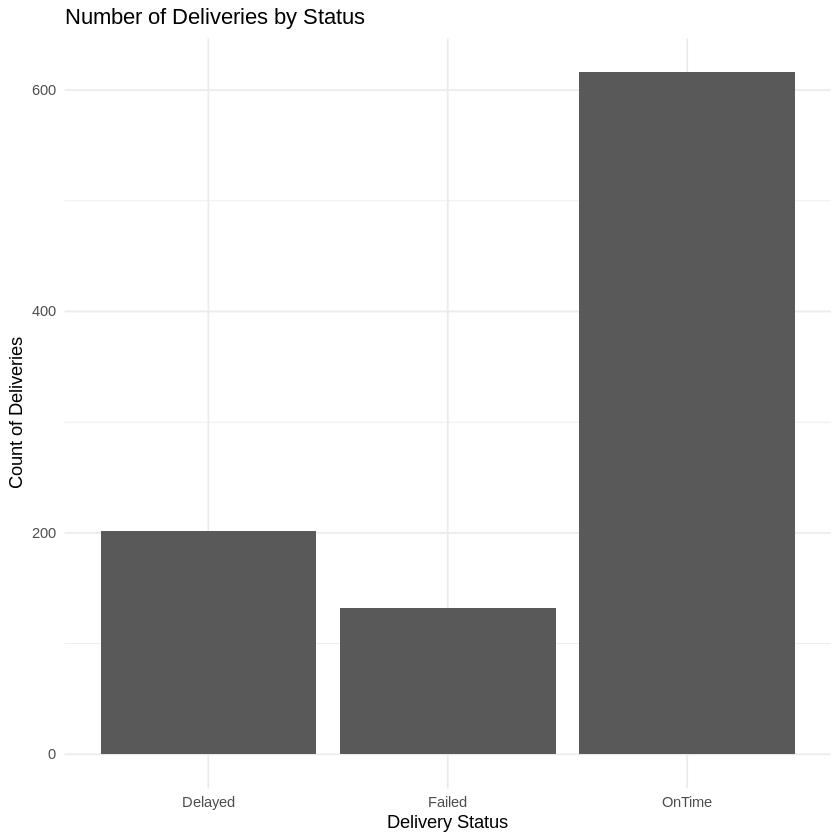

In [ ]:
library(ggplot2)

ggplot(deliveries, aes(x = delivery_status)) +
  geom_bar() +
  labs(
    title = "Number of Deliveries by Status",
    x = "Delivery Status",
    y = "Count of Deliveries"
  ) +
  theme_minimal()

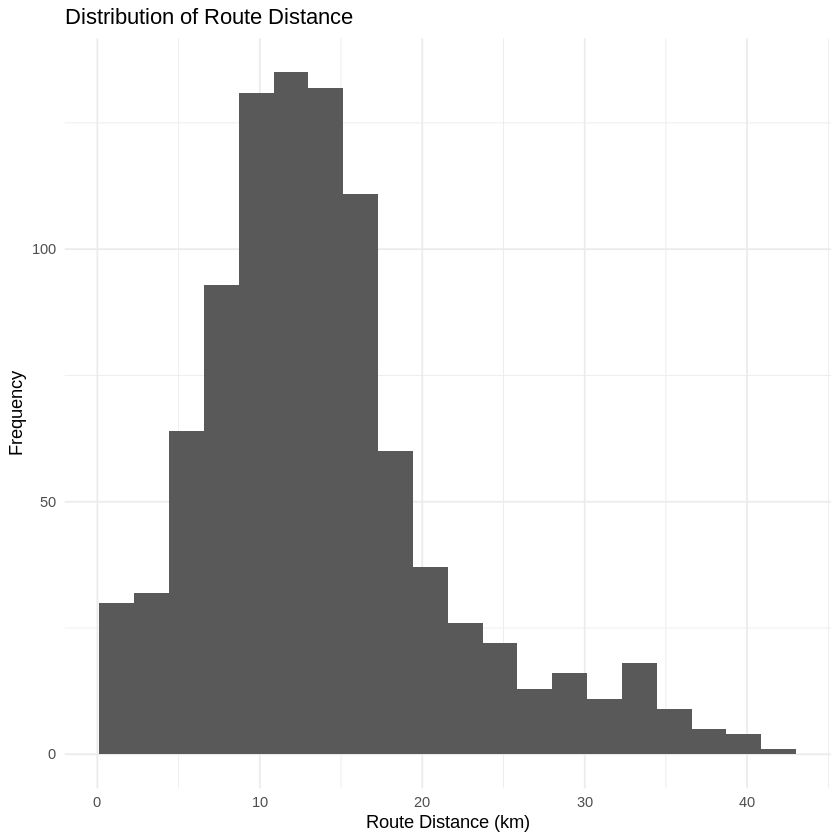

In [ ]:
library(ggplot2)

ggplot(deliveries, aes(x = route_distance_km)) +
  geom_histogram(bins = 20) +
  labs(
    title = "Distribution of Route Distance",
    x = "Route Distance (km)",
    y = "Frequency"
  ) +
  theme_minimal()

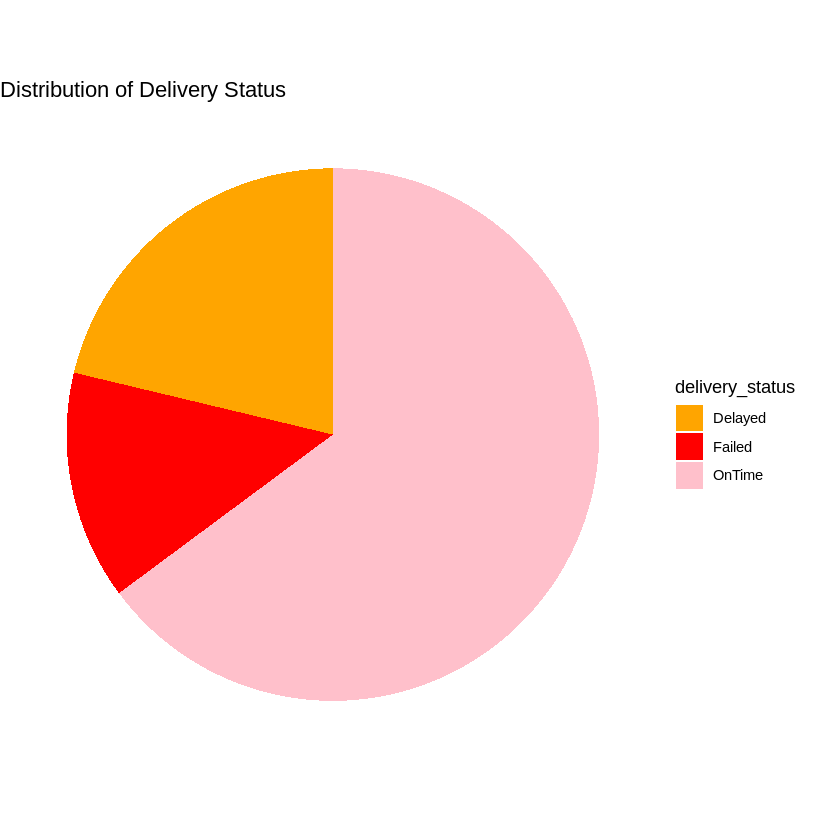

In [ ]:
ggplot(deliveries, aes(x = "", fill = delivery_status)) +
  geom_bar(width = 1) +
  coord_polar("y") +
  labs(title = "Distribution of Delivery Status") +
  scale_fill_manual(values = c(
    "Completed" = "green",
    "Delayed" = "orange",
    "Failed" = "red",
    "OnTime" = "pink"
  )) +
  theme_void()

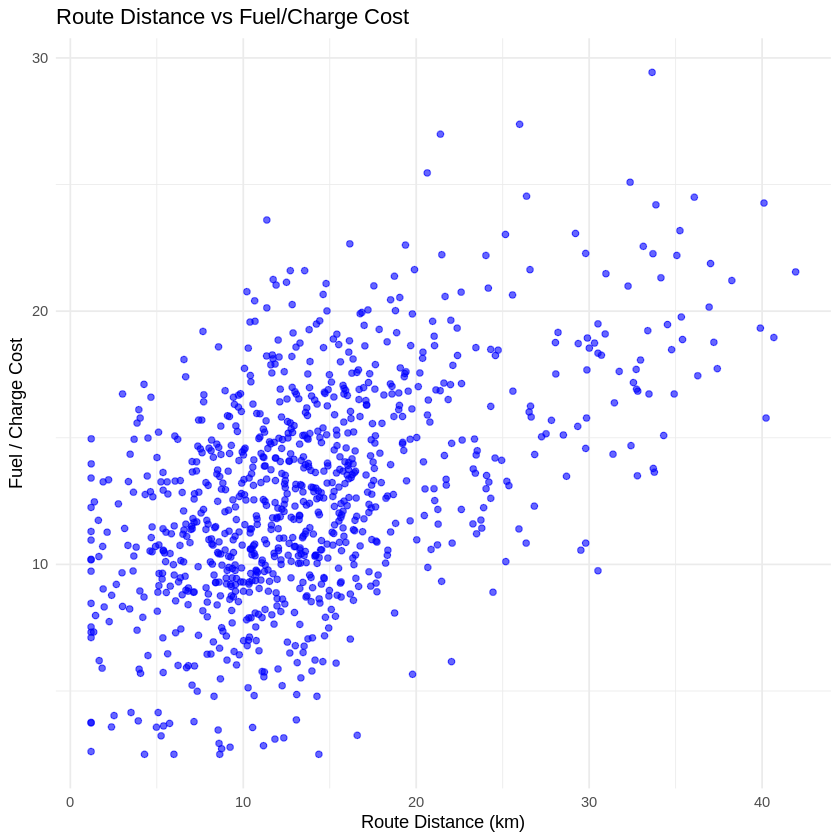

In [ ]:
library(ggplot2)

ggplot(deliveries, aes(x = route_distance_km, y = fuel_or_charge_cost)) +
  geom_point(color = "blue", alpha = 0.6) +
  labs(
    title = "Route Distance vs Fuel/Charge Cost",
    x = "Route Distance (km)",
    y = "Fuel / Charge Cost"
  ) +
  theme_minimal()

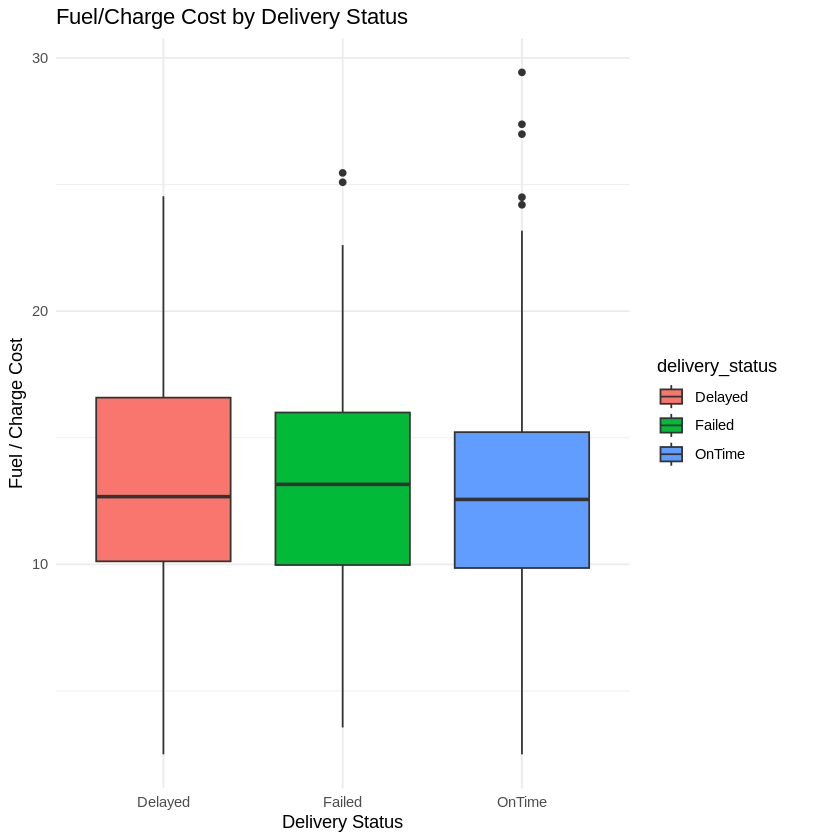

In [ ]:
library(ggplot2)

ggplot(deliveries, aes(x = delivery_status, y = fuel_or_charge_cost, fill = delivery_status)) +
  geom_boxplot() +
  labs(
    title = "Fuel/Charge Cost by Delivery Status",
    x = "Delivery Status",
    y = "Fuel / Charge Cost"
  ) +
  theme_minimal()